In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('data/Customer-Churn.csv')
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [7]:
print (df.columns)
print (len(df.columns))

Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value', 'Churn'],
      dtype='object')
14


In [33]:
df.describe()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,0.157143
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,0.363993
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


In [34]:
# churn details
df['Churn'].value_counts()

Churn
0    2655
1     495
Name: count, dtype: int64

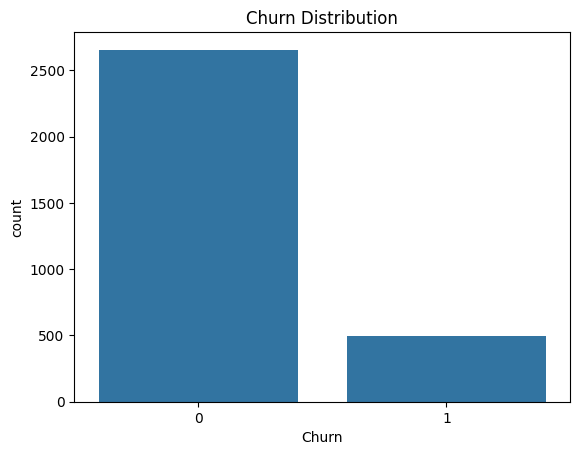

In [19]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

In [22]:
df['Complains'].value_counts()

Complains
0    2909
1     241
Name: count, dtype: int64

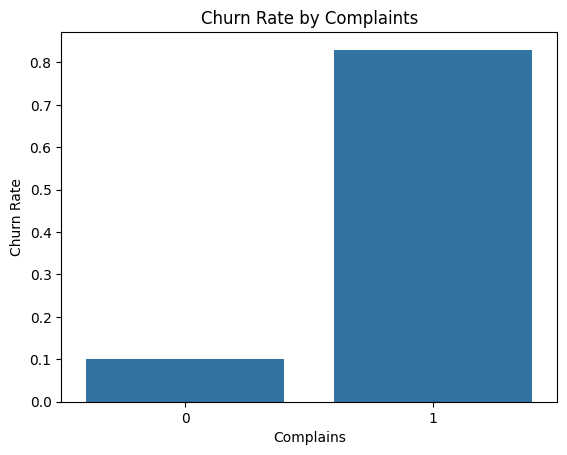

In [21]:
churn_rate = df.groupby('Complains')['Churn'].mean().reset_index()

sns.barplot(x='Complains', y='Churn', data=churn_rate)

plt.title('Churn Rate by Complaints')
plt.xlabel('Complains')
plt.ylabel('Churn Rate')
plt.show()

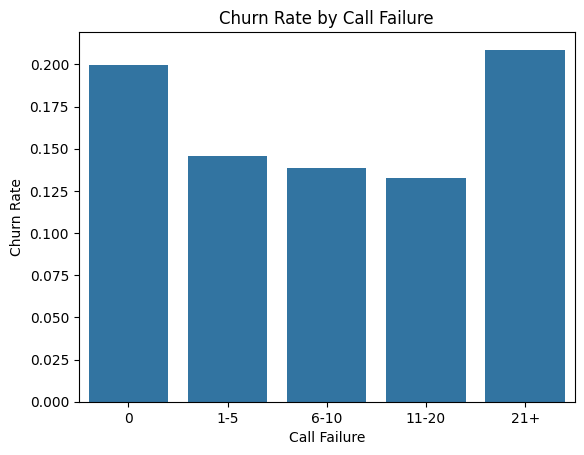

In [32]:
bins = [-1, 0, 5, 10, 20, float('inf')]
labels = ['0', '1-5', '6-10', '11-20', '21+']

df['Call Failure Group'] = pd.cut(
    df['Call  Failure'],
    bins=bins,
    labels=labels
)

churn_rate = (
    df.groupby('Call Failure Group', observed=True)['Churn']
      .mean()
      .reset_index()
)

sns.barplot(
    data=churn_rate,
    x='Call Failure Group',
    y='Churn'
)

plt.title('Churn Rate by Call Failure')
plt.xlabel('Call Failure')
plt.ylabel('Churn Rate')
plt.show()

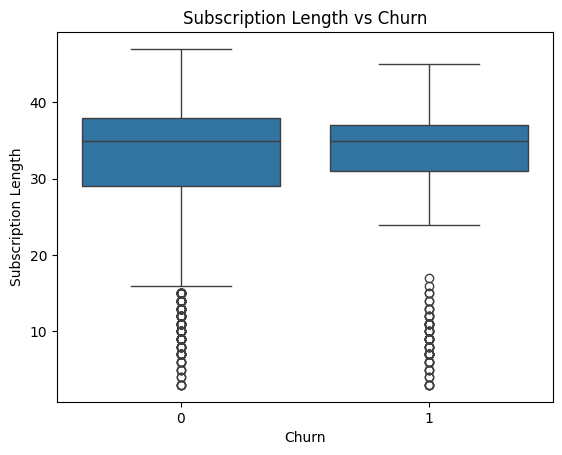

In [36]:
sns.boxplot(
    data=df,
    x='Churn',
    y='Subscription  Length'
)

plt.title('Subscription Length vs Churn')
plt.xlabel('Churn')
plt.ylabel('Subscription Length')
plt.show()

In [43]:
# setting up the base model
x = np.asarray(df[['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value']])
x[:5]

array([[8.00000e+00, 0.00000e+00, 3.80000e+01, 0.00000e+00, 4.37000e+03,
        7.10000e+01, 5.00000e+00, 1.70000e+01, 3.00000e+00, 1.00000e+00,
        1.00000e+00, 3.00000e+01, 1.97640e+02],
       [0.00000e+00, 0.00000e+00, 3.90000e+01, 0.00000e+00, 3.18000e+02,
        5.00000e+00, 7.00000e+00, 4.00000e+00, 2.00000e+00, 1.00000e+00,
        2.00000e+00, 2.50000e+01, 4.60350e+01],
       [1.00000e+01, 0.00000e+00, 3.70000e+01, 0.00000e+00, 2.45300e+03,
        6.00000e+01, 3.59000e+02, 2.40000e+01, 3.00000e+00, 1.00000e+00,
        1.00000e+00, 3.00000e+01, 1.53652e+03],
       [1.00000e+01, 0.00000e+00, 3.80000e+01, 0.00000e+00, 4.19800e+03,
        6.60000e+01, 1.00000e+00, 3.50000e+01, 1.00000e+00, 1.00000e+00,
        1.00000e+00, 1.50000e+01, 2.40020e+02],
       [3.00000e+00, 0.00000e+00, 3.80000e+01, 0.00000e+00, 2.39300e+03,
        5.80000e+01, 2.00000e+00, 3.30000e+01, 1.00000e+00, 1.00000e+00,
        1.00000e+00, 1.50000e+01, 1.45805e+02]])

In [42]:
y = np.asarray(df['Churn'])
y[:5]

array([0, 0, 0, 0, 0])

In [45]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print('this is the shape of x train and test:', x_train.shape, x_test.shape)
print('this is the shape of y train and test:', y_train.shape, y_test.shape)


this is the shape of x train and test: (2520, 13) (630, 13)
this is the shape of y train and test: (2520,) (630,)


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression()
model.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [49]:
y_pred = model.predict(x_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8698412698412699

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92       520
           1       0.73      0.40      0.52       110

    accuracy                           0.87       630
   macro avg       0.81      0.68      0.72       630
weighted avg       0.86      0.87      0.85       630



### عملکرد در شناسایی افرادی که خواستن برن ضعیف تر بود

In [50]:
model = LogisticRegression(class_weight='balanced')
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.83      0.89       520
           1       0.51      0.83      0.63       110

    accuracy                           0.83       630
   macro avg       0.73      0.83      0.76       630
weighted avg       0.88      0.83      0.85       630



این مدل برای این بیزینس معمولا کاربردی تر از مدل قبلی هست. 
در بیزینس، از دست دادن یک مشتری معمولاً هزینه‌برتر از این است که به اشتباه به یک مشتری وفادار تخفیف یا پیشنهاد ویژه بدهیم